In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("Company_Data.csv")
df

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes


In [35]:
df.isnull().sum()

Sales          0
CompPrice      0
Income         0
Advertising    0
Population     0
Price          0
ShelveLoc      0
Age            0
Education      0
Urban          0
US             0
dtype: int64

In [36]:
df.duplicated().sum()

0

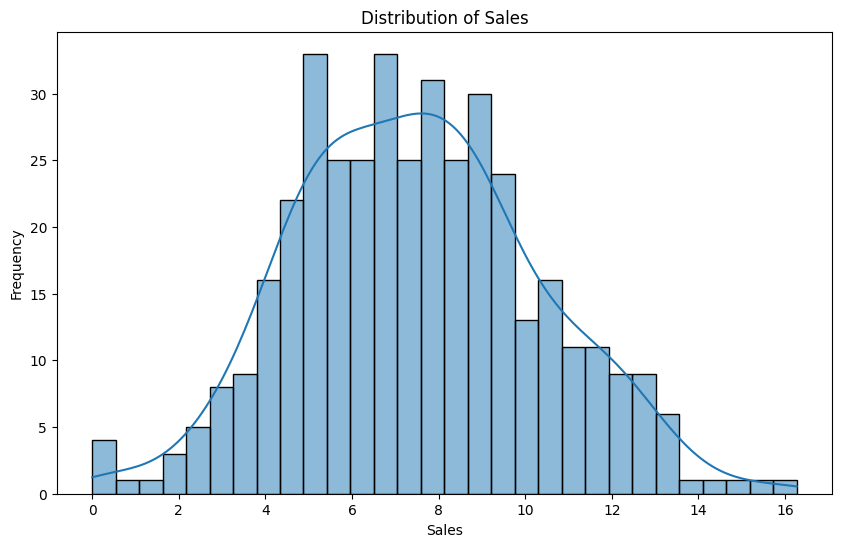

In [37]:
# Visualize the distribution of 'Sales'
plt.figure(figsize=(10, 6))
sns.histplot(df['Sales'], bins=30, kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

<Figure size 1500x1000 with 0 Axes>

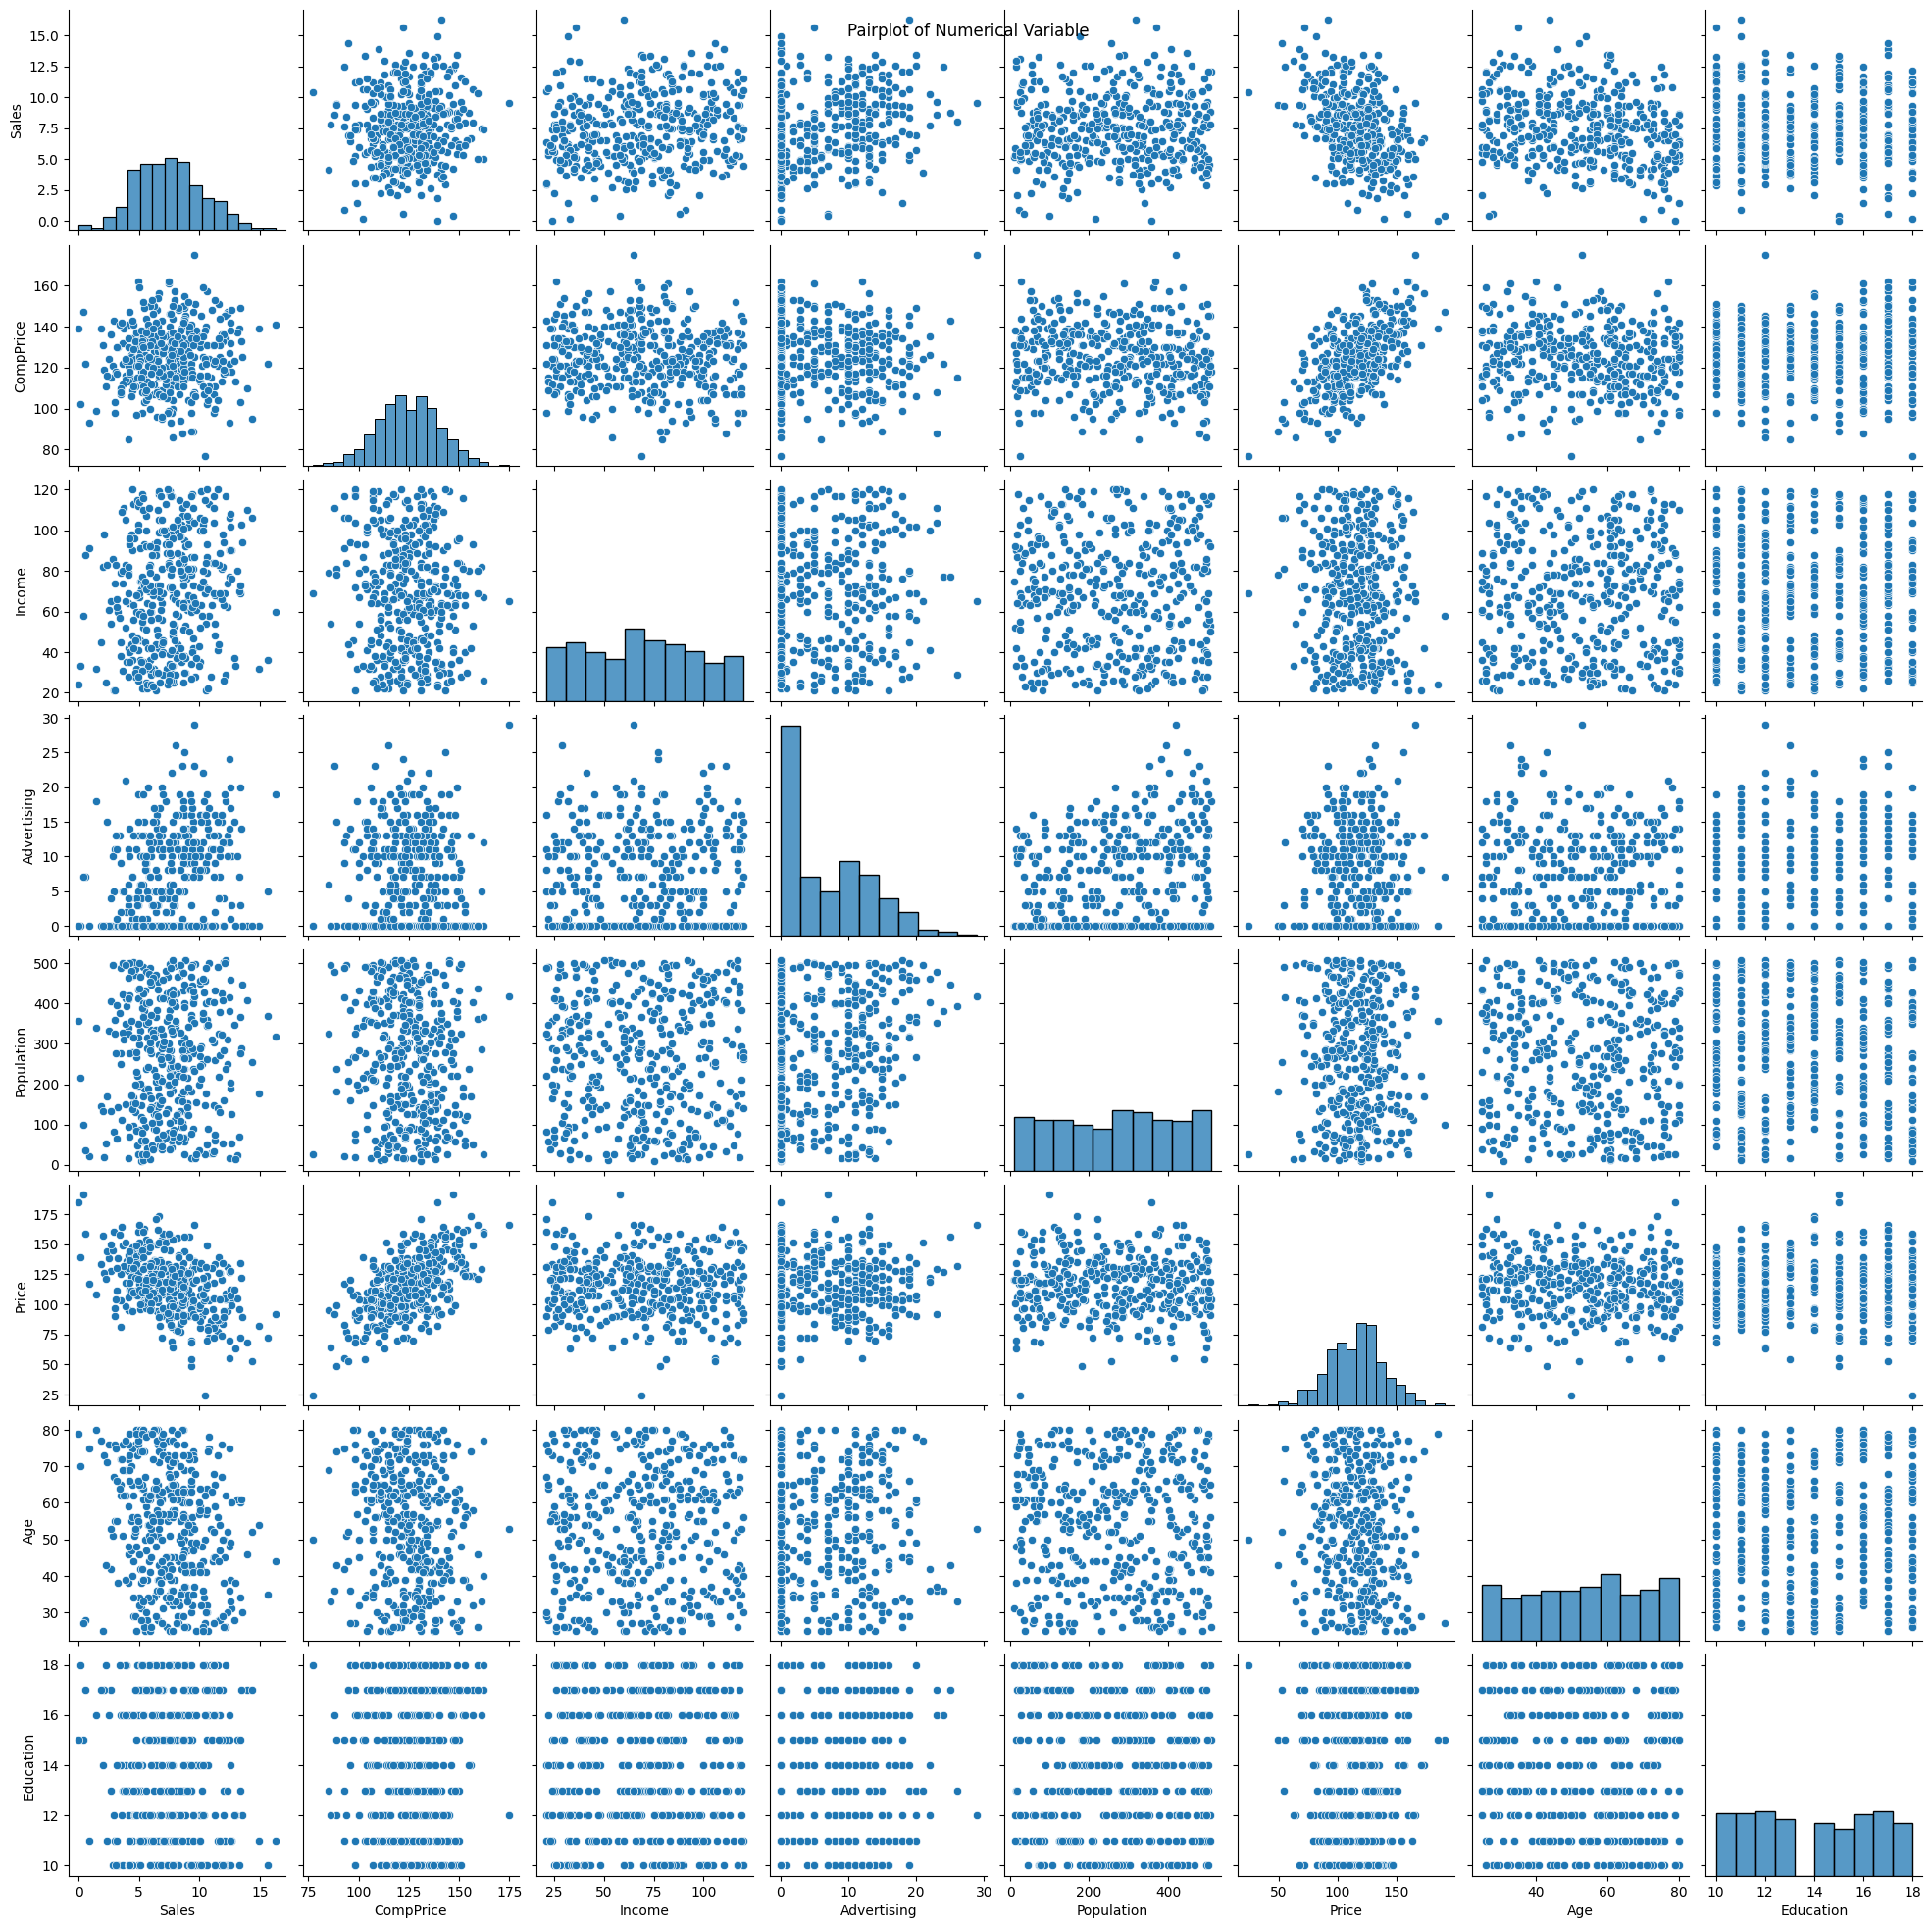

In [38]:
# Pairplot for numerical variables
numerical_columns = df.select_dtypes(include='number').columns
plt.figure(figsize=(15, 10))
sns.pairplot(df[numerical_columns])
plt.suptitle('Pairplot of Numerical Variable')
plt.show()


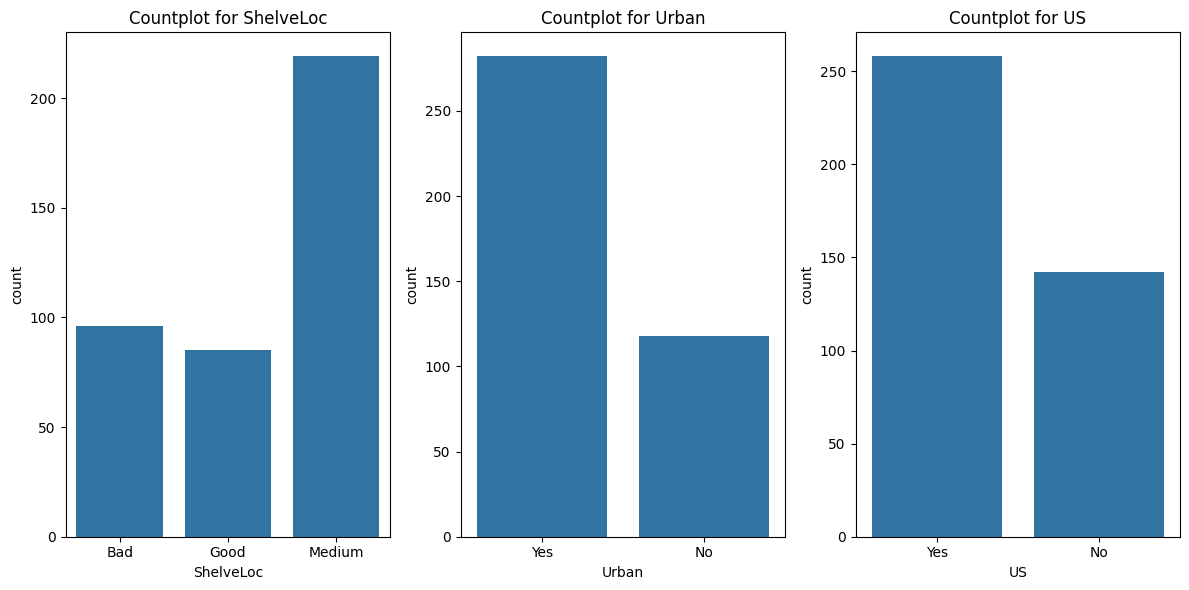

In [39]:
# Countplot for categorical variables
categorical_columns = ['ShelveLoc', 'Urban', 'US']
plt.figure(figsize=(12, 6))
for i, column in enumerate(categorical_columns, 1):
    plt.subplot(1, len(categorical_columns), i)
    sns.countplot(x=column, data=df)
    plt.title(f'Countplot for {column}')

plt.tight_layout()
plt.show()


In [40]:
# Convert the 'Sales' variable to a categorical variable
df['Sale_Category'] = pd.cut(df['Sales'], bins=[-float('inf'), df['Sales'].mean(), float('inf')], labels=['Low', 'High'])

In [41]:
df = df.drop('Sales', axis=1)

In [42]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
for column in categorical_columns + ['Sale_Category']:
    df[column] = label_encoder.fit_transform(df[column])


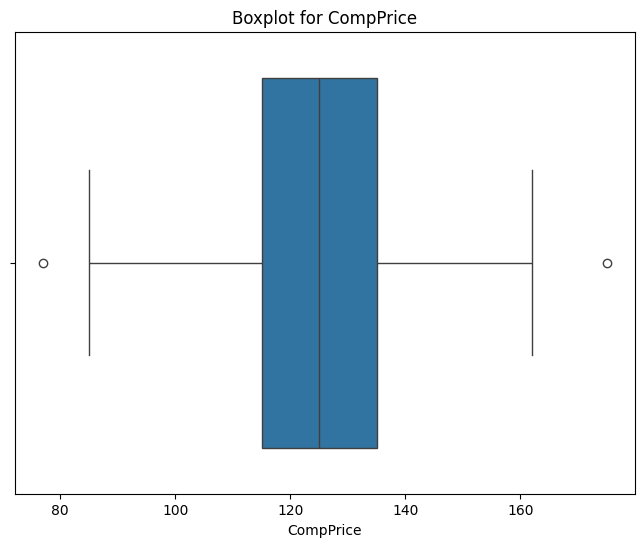

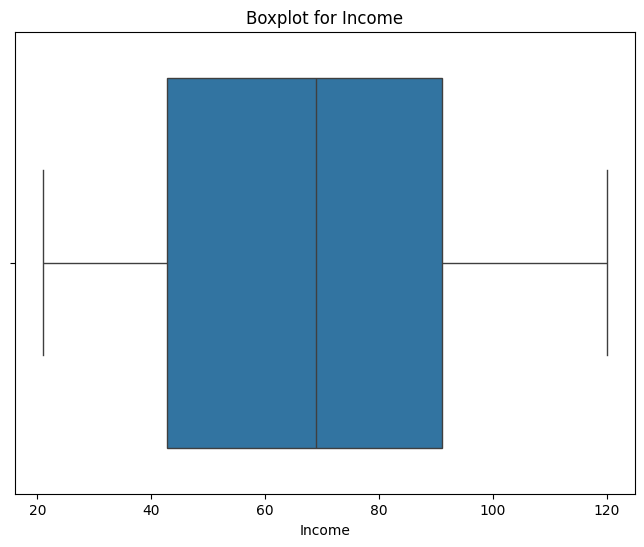

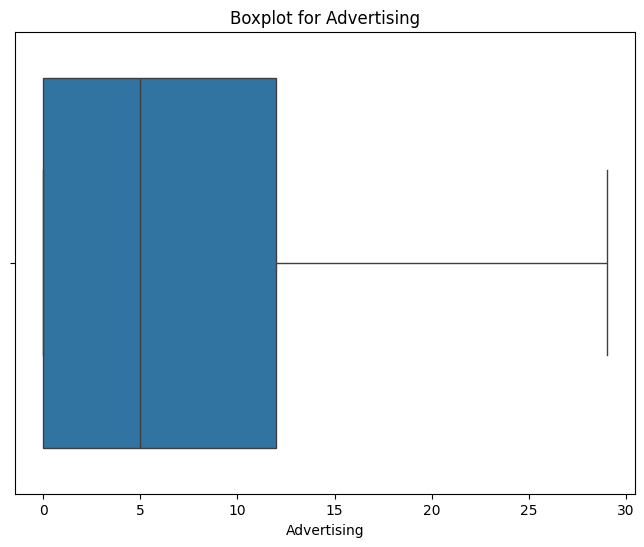

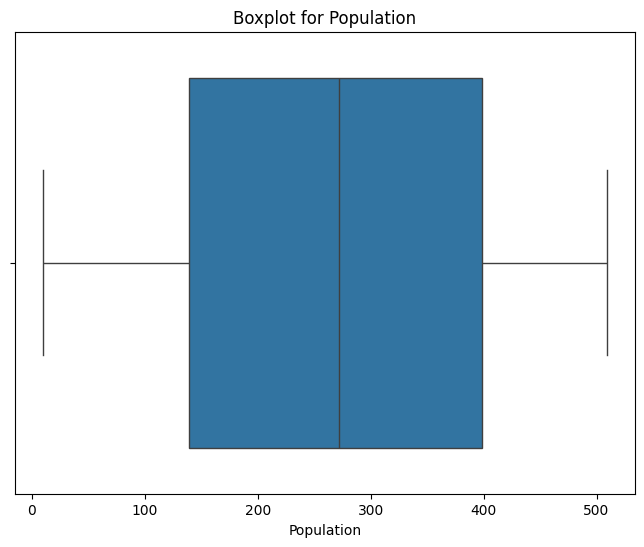

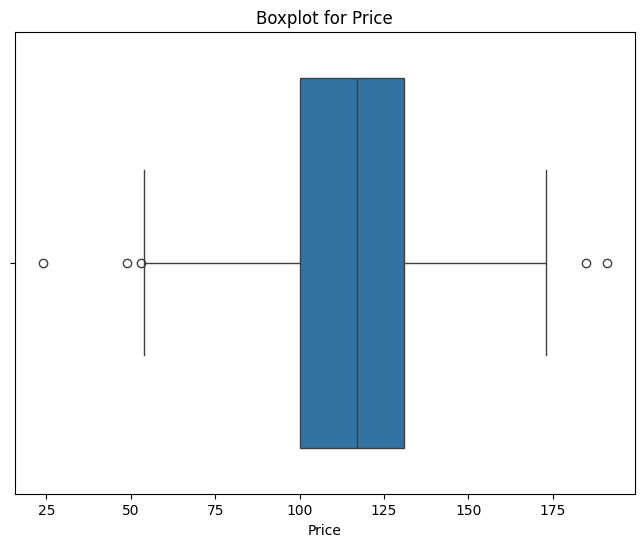

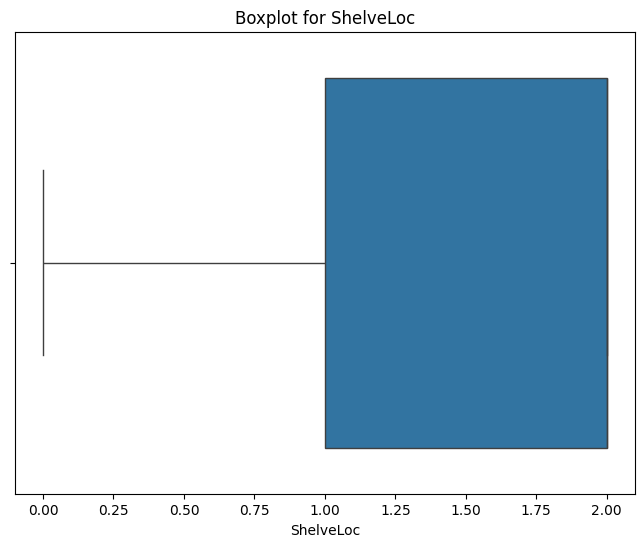

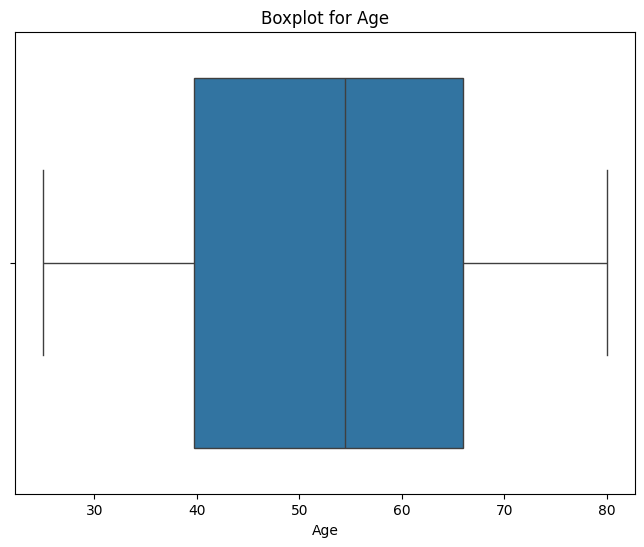

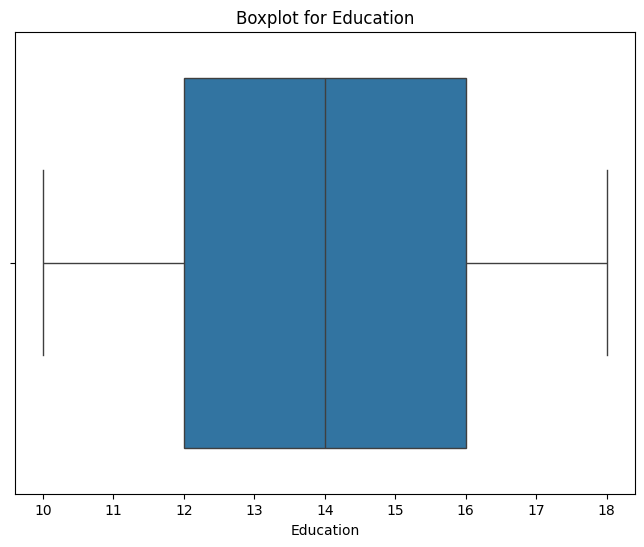

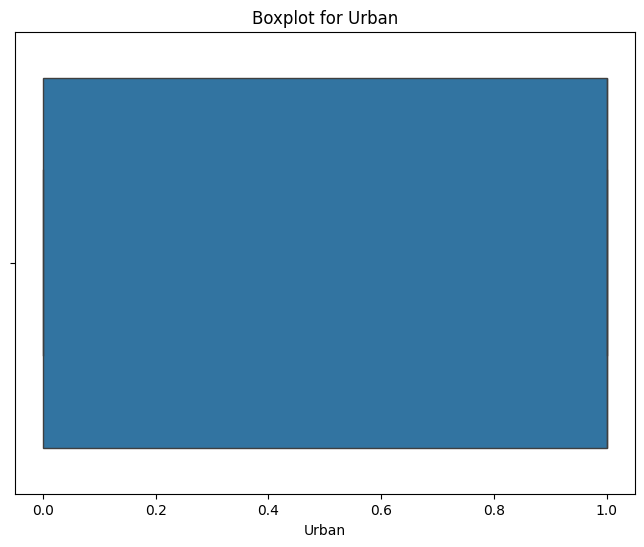

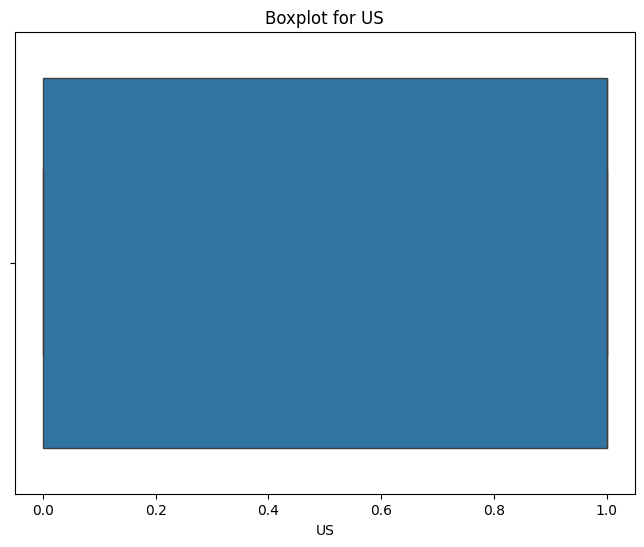

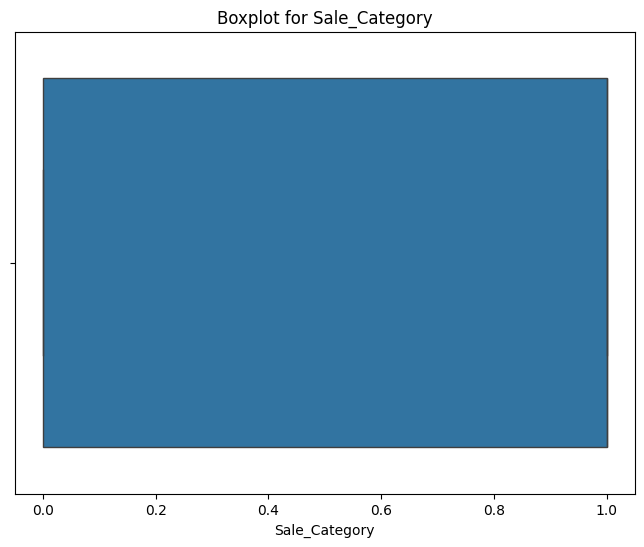

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

for column in df.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=column, data=df)
    plt.title(f'Boxplot for {column}')
    plt.show()


In [44]:
def replace_outliers(data, colname):
    q1 = data[colname].quantile(0.25)
    q3 = data[colname].quantile(0.75)
    iqr = q3 - q1

    upper = q3 + (1.5 * iqr)
    lower = q1 - (1.5 * iqr)


    outliers = (df[colname] < lower) | (df[colname] > upper)


    df[colname][outliers] = df[colname][outliers].apply(lambda x: upper if x > upper else lower)

    return data

In [45]:
df = replace_outliers(df, 'CompPrice')
df=replace_outliers(df,'Price')

In [46]:
X = df.drop('Sale_Category', axis=1)
y = df['Sale_Category']

In [47]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [49]:
y_pred_rf = random_forest.predict(X_test)

In [50]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
classification_rep_rf = classification_report(y_test, y_pred_rf)

In [51]:
print('Accuracy:',accuracy_rf)
print('Confusion Matrix:',conf_matrix_rf)
print('Classification Report:',classification_rep_rf)

Accuracy: 0.825
Confusion Matrix: [[35  8]
 [ 6 31]]
Classification Report:               precision    recall  f1-score   support

           0       0.85      0.81      0.83        43
           1       0.79      0.84      0.82        37

    accuracy                           0.82        80
   macro avg       0.82      0.83      0.82        80
weighted avg       0.83      0.82      0.83        80



In [52]:
tree_rules_rf = export_text(random_forest.estimators_[0], feature_names=list(X.columns))
print('Decision Tree Rules (Random Forest):', tree_rules_rf)

Decision Tree Rules (Random Forest): |--- Price <= 92.50
|   |--- Age <= 69.00
|   |   |--- ShelveLoc <= 0.50
|   |   |   |--- Population <= 196.00
|   |   |   |   |--- class: 1.0
|   |   |   |--- Population >  196.00
|   |   |   |   |--- class: 0.0
|   |   |--- ShelveLoc >  0.50
|   |   |   |--- Population <= 198.50
|   |   |   |   |--- Income <= 88.50
|   |   |   |   |   |--- class: 0.0
|   |   |   |   |--- Income >  88.50
|   |   |   |   |   |--- Age <= 56.50
|   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |--- Age >  56.50
|   |   |   |   |   |   |--- class: 1.0
|   |   |   |--- Population >  198.50
|   |   |   |   |--- class: 0.0
|   |--- Age >  69.00
|   |   |--- Urban <= 0.50
|   |   |   |--- class: 1.0
|   |   |--- Urban >  0.50
|   |   |   |--- class: 0.0
|--- Price >  92.50
|   |--- CompPrice <= 121.50
|   |   |--- CompPrice <= 106.50
|   |   |   |--- CompPrice <= 101.00
|   |   |   |   |--- Advertising <= 11.50
|   |   |   |   |   |--- class: 1.0
|   |   |   |   